In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rating_data = json.load(open('./data/behTab_wVA.json'))
movie_names_to_remove = ['DamagedKungFu', 'RidingTheRails','LeassonLearned']
categories = ['Anger', 'Anxiety', 'Fear', 'Surprise', 'Guilt', 'Disgust', 'Sad', 'Regard', 'Satisfaction', 'WarmHeartedness', 'Happiness', 'Pride', 'Love']
va_items = ['Good', 'Bad', 'Calm', 'AtEase']
rating_data = {movie: pd.DataFrame(rating_data[movie])[categories+va_items] for movie in rating_data.keys() if movie not in movie_names_to_remove}
# concatenate all films
all_ratings = pd.concat(rating_data.values())

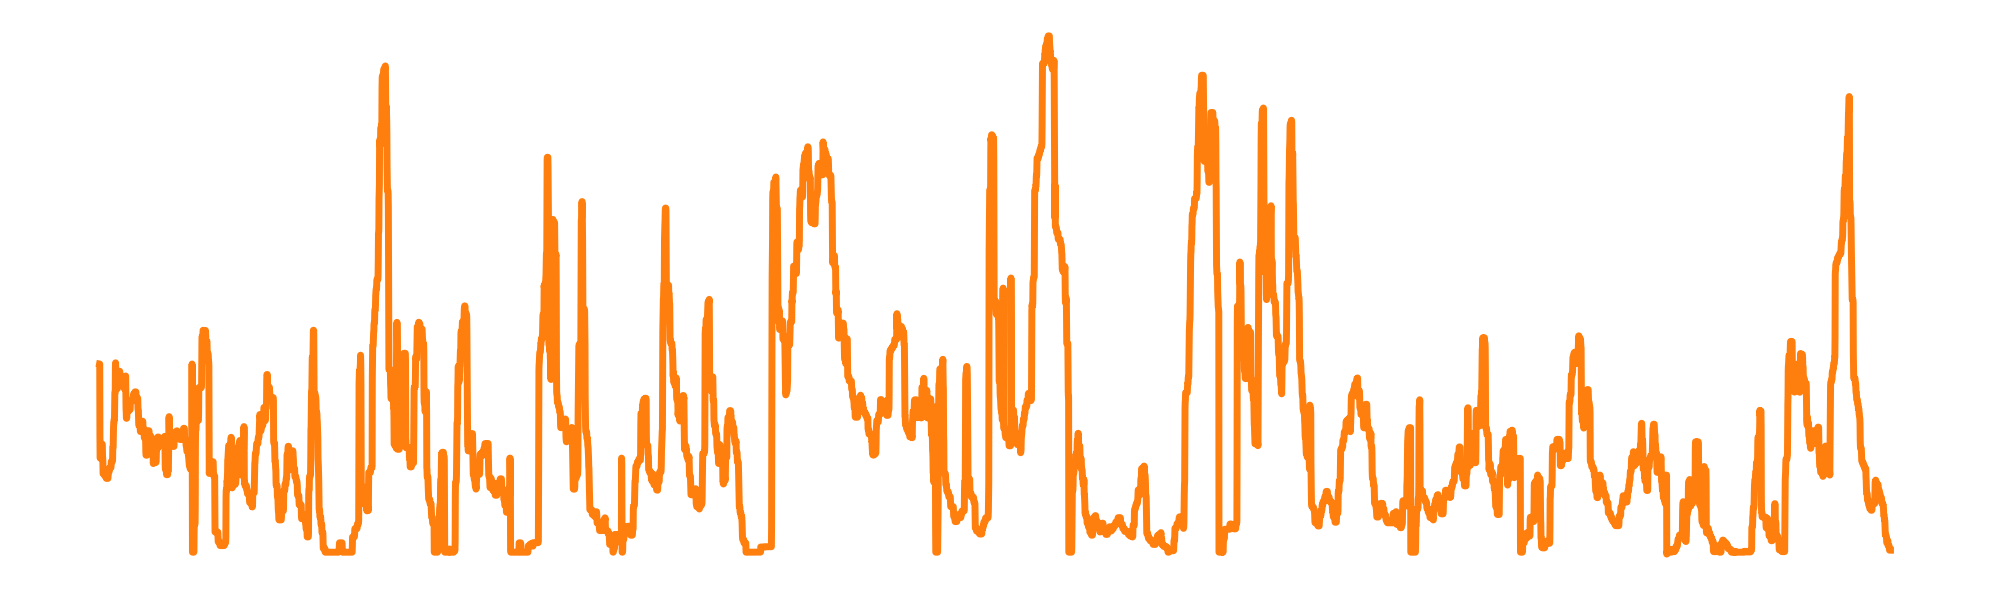

In [3]:
# Plot timeseries of emotion categories for 'Superhero' film
categories_to_plot = ['Anger']
plt.figure(figsize=(20,6))
#plt.plot(rating_data['Superhero'][categories_to_plot], color='#1f77b4', linewidth=6)
plt.plot(all_ratings[categories_to_plot].values, color='#ff7f0e', linewidth=5)
#plt.title("Emotion Categories Over Time - 'Superhero'")
#plt.xlabel('Timepoint')
#plt.ylabel('Rating')
#plt.legend(categories_to_plot, bbox_to_anchor=(1.05, 1), loc='upper left')
#remove x, y ticks, labels, spines
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.tight_layout()
plt.show()


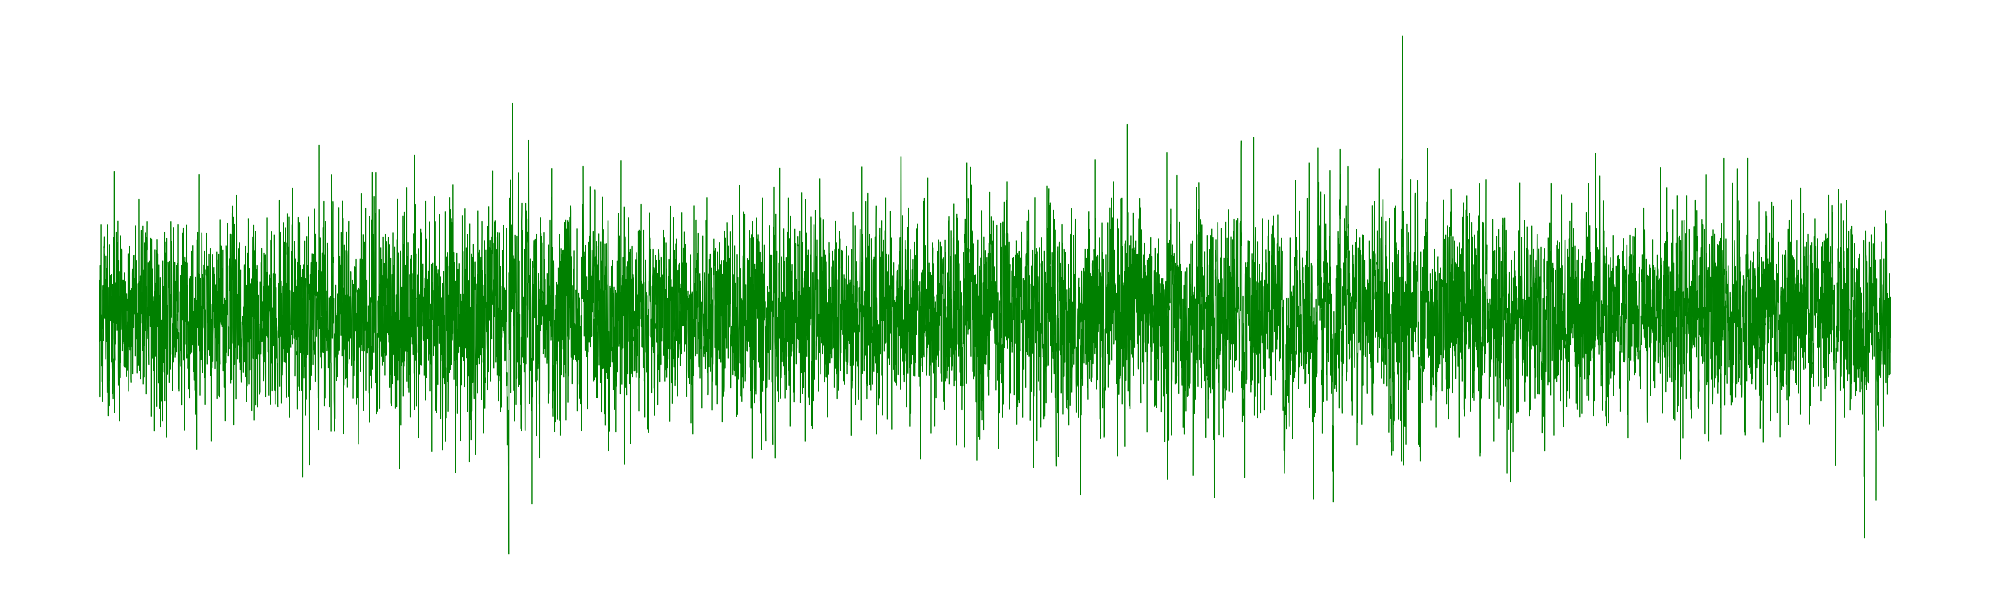

In [4]:
hc_ts = pd.read_csv('./outputs/hc_allfilms_3vols_ts.csv', header=None) #no column name row
#plot hc_ts
plt.figure(figsize=(20,6))
plt.plot(hc_ts.T[2],color='green',linewidth=0.5)
#plt.title("HC Timeseries - 'Superhero'")
#plt.xlabel('Timepoint')
#plt.ylabel('Rating')
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

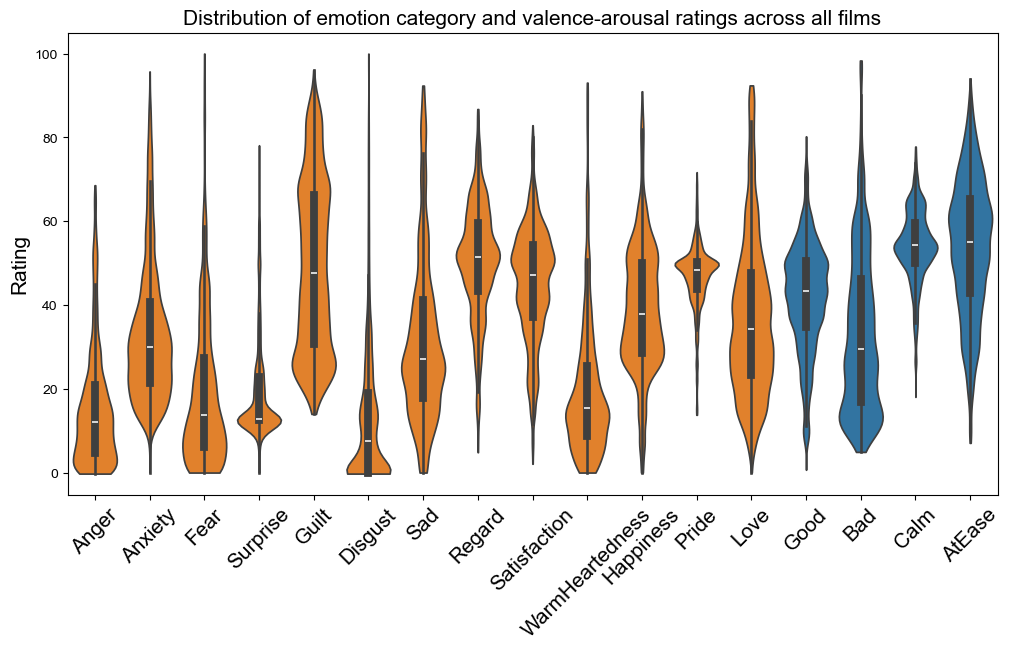

In [7]:

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(12,6))
sns.violinplot(data=all_ratings[categories+va_items], inner='box', cut=0, 
               palette=['#ff7f0e']*len(categories) + ['#1f77b4']*len(va_items))
plt.xticks(rotation=45, fontsize=15)
plt.ylabel('Rating', fontsize=15)
plt.title('Distribution of emotion category and valence-arousal ratings across all films', fontsize=15)
#plt.savefig('./outputs/rating_distribution_across_films.jpeg', dpi=600, bbox_inches='tight')
plt.show()

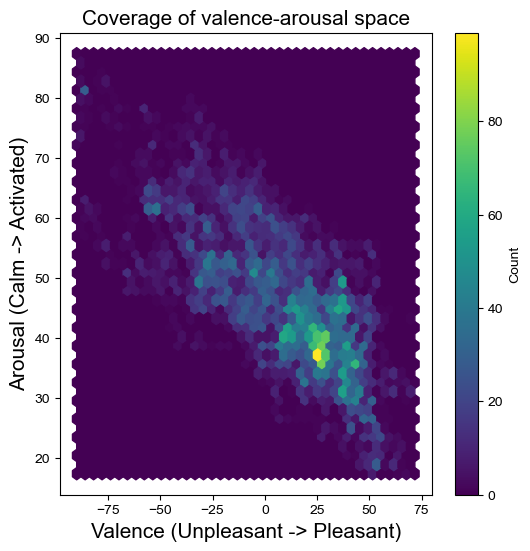

In [8]:
valence = (all_ratings['Good'] - all_ratings['Bad'])
arousal = 100-(all_ratings[['Calm','AtEase']].sum(axis=1))/2

plt.figure(figsize=(6,6))
plt.hexbin(valence, arousal, gridsize=40, cmap='viridis')
plt.colorbar(label='Count')
plt.xlabel('Valence (Unpleasant -> Pleasant)', fontsize=15)
plt.ylabel('Arousal (Calm -> Activated)', fontsize=15)
plt.title('Coverage of valence-arousal space', fontsize=15)
#plt.axhline(0, color='gray', linestyle='--', linewidth=1)
#plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

/home/yma/envs/netana_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yma/envs/netana_env/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


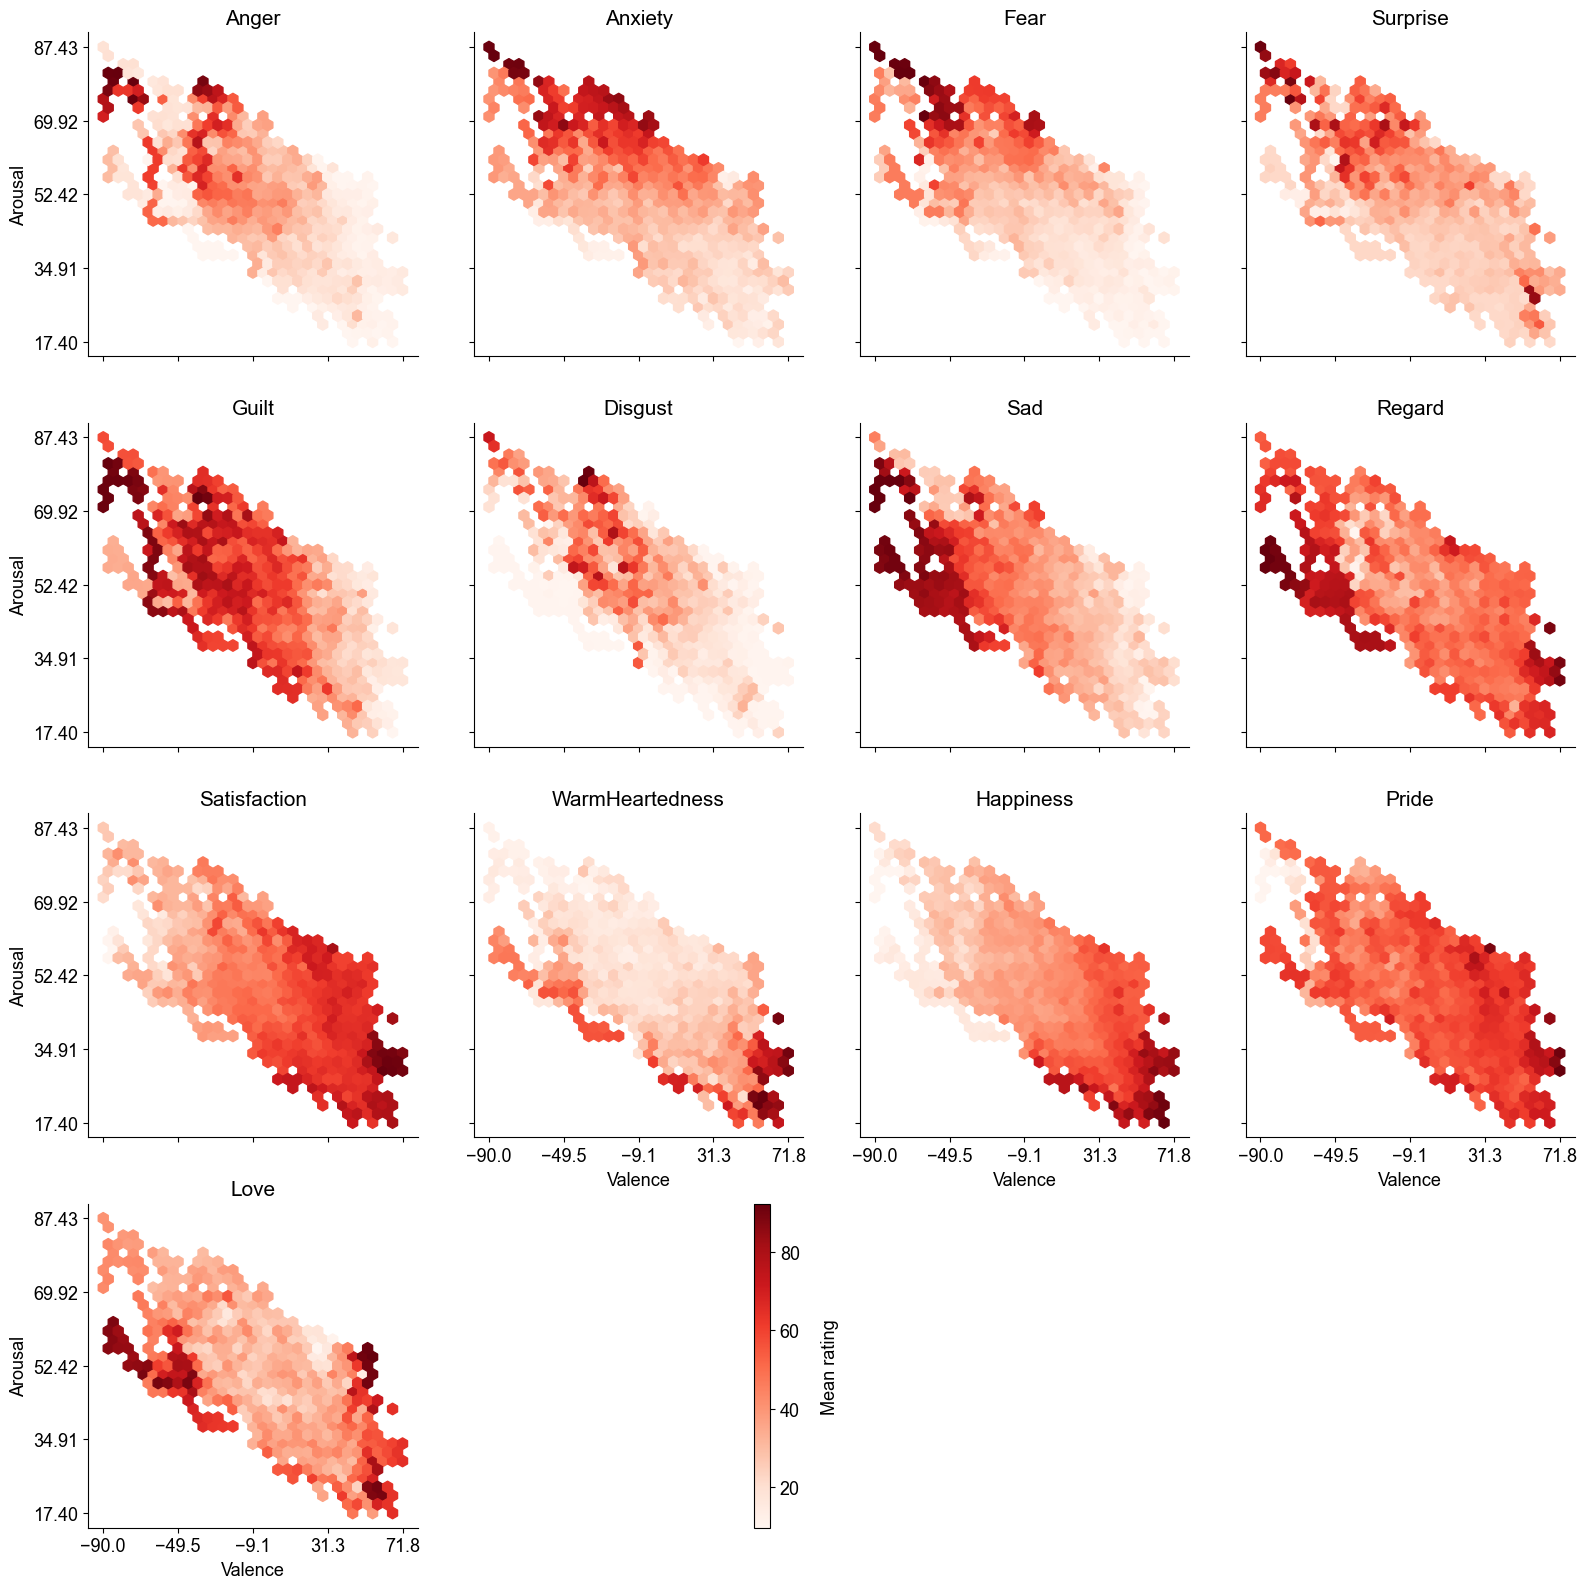

In [9]:
valence = (all_ratings['Good'] - all_ratings['Bad'])
arousal = 100-(all_ratings[['Calm','AtEase']].sum(axis=1))/2

fig, axes = plt.subplots(4, 4, figsize=(16,16))
axes = axes.flatten()

last_hb = None
for i, category in enumerate(categories):
    ax = axes[i]
    hb = ax.hexbin(valence, arousal, C=all_ratings[category],reduce_C_function=np.mean, gridsize=30, cmap="Reds")
    last_hb = hb
    ax.set_ylabel("Arousal", fontsize=13)
    ax.set_xlabel("Valence", fontsize=13)
    ax.set_title(category, fontsize=15)
    #set ticks size
    ax.tick_params(axis='both', which='major', labelsize=13)
    #set ticks number to 5
    ax.set_xticks(np.linspace(valence.min(), valence.max(), 5))
    ax.set_yticks(np.linspace(arousal.min(), arousal.max(), 5))
    #remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# remove last 3 axes 
for ax in axes[13:]:
    ax.axis('off')

#ticks and labels
nrows, ncols = 4, 4
for i, ax in enumerate(axes):
    row, col = divmod(i, ncols)
    if i >= len(categories):  # skip empty slots
        continue
    #show y ticks/labels only for first column
    if col != 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    #show x ticks/labels only for bottom row
    if row != nrows-1 and row != nrows-2:
        ax.set_xticklabels([])
        ax.set_xlabel("")

for col in [1,2,3]:
    ax = axes[(nrows-2)*ncols + col]  #second last row, col 1-3
    ax.set_xlabel("Valence", fontsize=13)
#remove xticklabel for the ax 8
axes[8].set_xticklabels([])
axes[8].set_xlabel("")

#colorbar
cax = axes[13]  
cbar = fig.colorbar(last_hb, ax=cax)
cbar.set_label("Mean rating", fontsize=13, rotation=90, labelpad=15)
#set ticks size
cbar.ax.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
#plt.savefig("./outputs/vaHexbin_allCates.jpeg", dpi=600)
plt.show()


/home/yma/envs/netana_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yma/envs/netana_env/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 640x480 with 0 Axes>

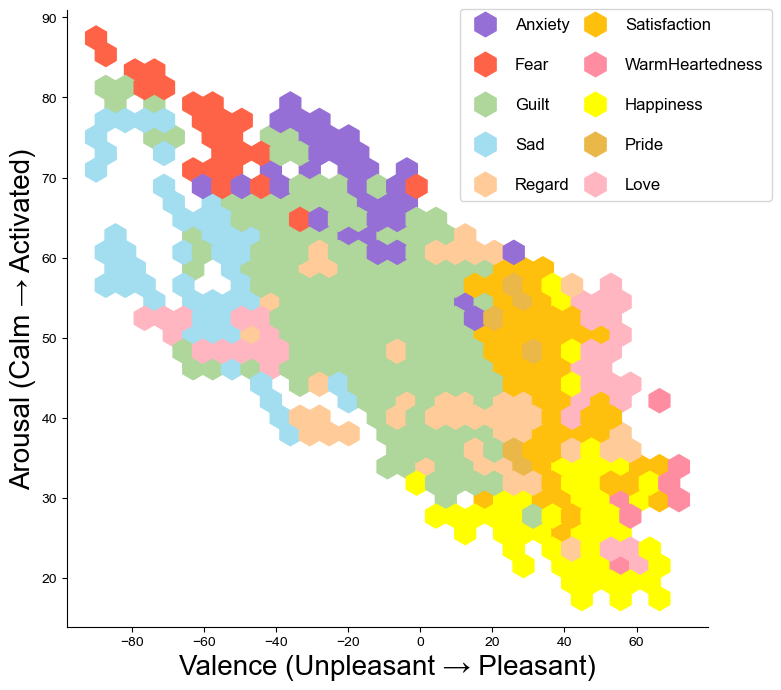

In [10]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.sans-serif'] = ['Arial']

category_to_color = {
    'Anger': 'orangered',
    'Anxiety': '#966fd6',#'violet',
    'Fear': 'tomato',
    'Surprise': '#77DD77',
    'Guilt': '#afd69b',#'#FFDAC1',
    'Disgust': '#D4A5A5',
    'Sad': '#A2DDF0',
    'Regard': '#FFCC99',
    'Satisfaction': '#FFBF0D',#'#FFD700',
    'WarmHeartedness': '#FF8DA1',#'#FFE5B4',
    'Happiness': '#FFFF00',
    'Pride': '#EAB749',#'#FFEB3B',
    'Love': '#FFB6C1'
}

valence = (all_ratings['Good'] - all_ratings['Bad'])
arousal = 100-(all_ratings[['Calm','AtEase']].sum(axis=1))/2

gridsize = 30
extent = (valence.min(), valence.max(), arousal.min(), arousal.max())

#run one hexbin just to define the grid
hb = plt.hexbin(valence, arousal, C=all_ratings[categories[0]],reduce_C_function=np.mean, gridsize=gridsize, extent=extent, visible=False)
offsets = hb.get_offsets()
plt.clf()

#get mean intensity per bin for each category
bin_values = np.zeros((len(offsets), len(categories)))
for j, cat in enumerate(categories):
    hb = plt.hexbin(valence, arousal, C=all_ratings[cat],reduce_C_function=np.mean, gridsize=gridsize, extent=extent, visible=False)
    bin_values[:, j] = hb.get_array()
    plt.clf()

# get the max category for each bin
winner_int = np.nanargmax(bin_values, axis=1)

#deal with colors
bin_colors = []
for winner_idx in winner_int:
    winner_cat = categories[winner_idx]
    color = category_to_color[winner_cat]
    bin_colors.append(color)

#plot
plt.figure(figsize=(8,7))

scatter = plt.scatter(offsets[:,0], offsets[:,1],c=bin_colors, marker='h', s=300)

#deal with legend
handles = []
unique_winners = np.unique(winner_int)
for winner_idx in sorted(unique_winners):
    cat_name = categories[winner_idx]
    color = category_to_color[cat_name]
    handle = plt.Line2D([0],[0], marker='h', color='w',markerfacecolor=color, markersize=20, label=cat_name)
    handles.append(handle)
plt.legend(handles=handles, bbox_to_anchor=(0.6,1.015), loc='upper left', labelspacing=1.5, handletextpad=0.8, borderaxespad=0.5,ncol=2,borderpad=0.5,columnspacing=0.5,fontsize=12)

plt.xlabel("Valence (Unpleasant → Pleasant)", fontsize=20)
plt.ylabel("Arousal (Calm → Activated)", fontsize=20)
#plt.title("Dominant categories across valence–arousal space", fontsize=20)

#make the axes the same length
#plt.gca().set_aspect("equal", adjustable="box")
#remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('./outputs/vaHexbin_dominantCate.jpeg', dpi=600, bbox_inches='tight')
plt.show()